<a href="https://colab.research.google.com/github/Saideshmukh717/movie-project-for-microsoft/blob/main/01_EDA_Entertainment_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

In [218]:
#load dataset
movies = pd.read_csv('/content/content/tmdb_5000_movies.csv')
rating = pd.read_csv('/content/content/tmdb_5000_credits.csv', on_bad_lines='warn', engine='python')
# Ensure vote_count is in movies
print("Columns in movies raw:", 'vote_count' in movies.columns)

Columns in movies raw: True


/tmp/ipykernel_10637/1864353094.py:3: ParserWarning: Skipping line 754: unexpected end of data

  rating = pd.read_csv('/content/content/tmdb_5000_credits.csv', on_bad_lines='warn', engine='python')


In [219]:
#Merge on title
movies = movies.merge(rating, on='title')

In [220]:
print(movies.shape)
movies.head()

(752, 23)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [221]:
if 'cast_y' not in movies.columns:
    print("Error: Columns missing. Please ensure you run the merge cell (hAuEfoz9xXVR) before this cell.")
else:
    required_cols = ['movie_id_y', 'title', 'overview', 'genres', 'keywords', 'cast_y', 'crew_y']
    if 'vote_count' in movies.columns:
        required_cols.append('vote_count')
    elif 'vote_count_x' in movies.columns:
        required_cols.append('vote_count_x')

    movies = movies[required_cols].copy()
    if 'vote_count_x' in movies.columns:
        movies = movies.rename(columns={'vote_count_x': 'vote_count'})

    print("Columns successfully selected.")
    display(movies.head(10))

Error: Columns missing. Please ensure you run the merge cell (hAuEfoz9xXVR) before this cell.


In [222]:
movies.isnull().sum()

movies.dropna(inplace=True)

In [223]:
import ast

In [224]:
def convert(obj):
    # If it's already a list, just return it
    if isinstance(obj, list):
        return obj

    # If it's a string, parse it
    L = []
    for i in ast.literal_eval(obj):
        L.append(i['name'])
    return L

movies['genres'] = movies['genres'].apply(convert)
movies['keywords'] = movies['keywords'].apply(convert)

In [225]:
def convert_cast(text):
    # If the text is already a list (already processed), return it
    if isinstance(text, list):
        return text[:3]

    L = []
    counter = 0
    try:
        for i in ast.literal_eval(text):
            if counter < 3:
                L.append(i['name'])
                counter += 1
            else:
                break
    except (ValueError, SyntaxError):
        return []
    return L

# Identify if the column is 'cast_y' or simply 'cast'
target_col = 'cast_y' if 'cast_y' in movies.columns else 'cast'

if target_col in movies.columns:
    movies['cast'] = movies[target_col].apply(convert_cast)
    print(f"Successfully processed cast from column: {target_col}")
else:
    print("Error: Neither 'cast_y' nor 'cast' columns were found in the dataframe.")

Successfully processed cast from column: cast


In [226]:
def fetch_director(text):
    # If it's already a list, return it
    if isinstance(text, list):
        return text

    L = []
    try:
        for i in ast.literal_eval(text):
            if i.get('job') == 'Director':
                L.append(i['name'])
    except (ValueError, SyntaxError):
        return []
    return L

# Dynamically identify the crew column
target_crew_col = 'crew_y' if 'crew_y' in movies.columns else 'crew'

if target_crew_col in movies.columns:
    movies['crew'] = movies[target_crew_col].apply(fetch_director)
    print(f"Successfully processed director from column: {target_crew_col}")
else:
    print("Error: Neither 'crew_y' nor 'crew' columns were found.")

Successfully processed director from column: crew


In [227]:
# Convert overview into list
movies['overview'] = movies['overview'].apply(lambda x: x.split())

# Remove spaces inside words (important for ML)
def collapse(L):
    return [i.replace(" ", "") for i in L]

movies['genres'] = movies['genres'].apply(collapse)
movies['keywords'] = movies['keywords'].apply(collapse)
movies['cast'] = movies['cast'].apply(collapse)
movies['crew'] = movies['crew'].apply(collapse)

In [228]:
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']

# Standardize to the columns available: 'id' or 'movie_id_y'
target_id_col = 'id' if 'id' in movies.columns else 'movie_id_y'

new_df = movies[[target_id_col, 'title', 'tags']]
new_df.head()

,id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."


In [229]:
new_df.head(10)

,id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
5,559,Spider-Man 3,"[The, seemingly, invincible, Spider-Man, goes,..."
6,38757,Tangled,"[When, the, kingdom's, most, wanted-and, most,..."
7,99861,Avengers: Age of Ultron,"[When, Tony, Stark, tries, to, jumpstart, a, d..."
8,767,Harry Potter and the Half-Blood Prince,"[As, Harry, begins, his, sixth, year, at, Hogw..."
9,209112,Batman v Superman: Dawn of Justice,"[Fearing, the, actions, of, a, god-like, Super..."


In [230]:
# Define df before using it
df = movies.copy()

# Convert genres
def convert(text):
    # Check if already a list to avoid literal_eval error
    if isinstance(text, list):
        return text
    L = []
    for i in ast.literal_eval(text):
        L.append(i['name'])
    return L

df['genres'] = df['genres'].apply(convert)

# Note: 'release_date' was dropped in a previous cell (wX4DlE2E23QP).
# If you need it, you must go back and include it in that cell's selection.
if 'release_date' in df.columns:
    df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,status,tagline,title,vote_average,vote_count,movie_id,cast,crew,tags,year
0,237000000,"[Action, Adventure, Fantasy, ScienceFiction]",http://www.avatarmovie.com/,19995,"[cultureclash, future, spacewar, spacecolony, ...",en,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],"[In, the, 22nd, century,, a, paraplegic, Marin...",2009
1,300000000,"[Adventure, Fantasy, Action]",http://disney.go.com/disneypictures/pirates/,285,"[ocean, drugabuse, exoticisland, eastindiatrad...",en,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski],"[Captain, Barbossa,, long, believed, to, be, d...",2007
2,245000000,"[Action, Adventure, Crime]",http://www.sonypictures.com/movies/spectre/,206647,"[spy, basedonnovel, secretagent, sequel, mi6, ...",en,Spectre,"[A, cryptic, message, from, Bond’s, past, send...",107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes],"[A, cryptic, message, from, Bond’s, past, send...",2015
3,250000000,"[Action, Crime, Drama, Thriller]",http://www.thedarkknightrises.com/,49026,"[dccomics, crimefighter, terrorist, secretiden...",en,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...",112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan],"[Following, the, death, of, District, Attorney...",2012
4,260000000,"[Action, Adventure, ScienceFiction]",http://movies.disney.com/john-carter,49529,"[basedonnovel, mars, medallion, spacetravel, p...",en,John Carter,"[John, Carter, is, a, war-weary,, former, mili...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton],"[John, Carter, is, a, war-weary,, former, mili...",2012


In [231]:
genres = df['genres'].explode()

genre_counts = genres.value_counts().head(10)

print(genre_counts)

genres
Action            209
Adventure         198
Comedy            123
Family            110
Thriller          101
Fantasy           101
Drama              99
ScienceFiction     99
Animation          84
Crime              45
Name: count, dtype: int64


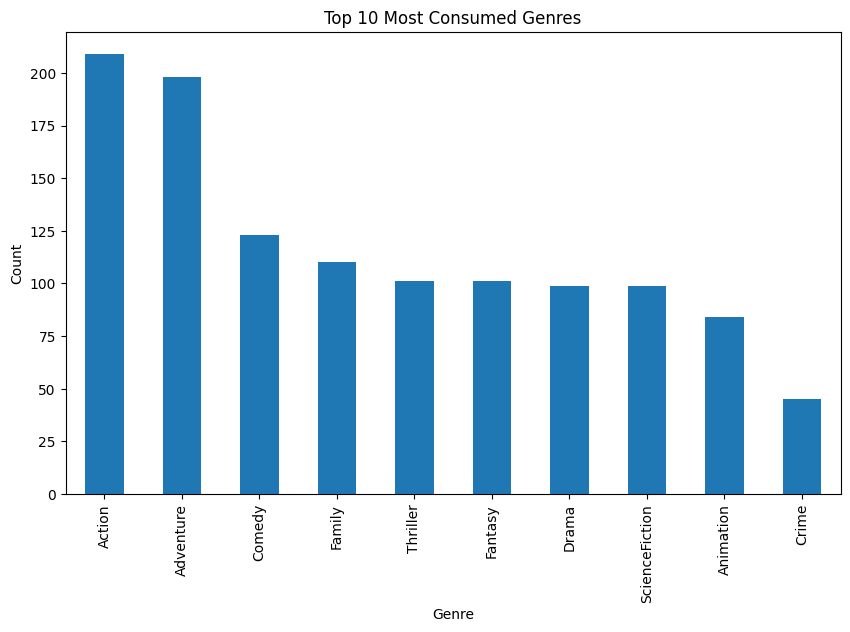

In [232]:


genre_counts.plot(kind='bar', figsize=(10,6))
plt.title("Top 10 Most Consumed Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

“Genres like Drama, Comedy, and Action dominate user consumption, indicating mainstream audience preference toward emotionally engaging and fast-paced content.”

In [233]:
top_engaged = df.sort_values(by='vote_count', ascending=False).head(10)
print(top_engaged[['title','vote_count']])

                       title  vote_count
96                 Inception       13752
65           The Dark Knight       12002
0                     Avatar       11800
16              The Avengers       11776
95              Interstellar       10867
287         Django Unchained       10099
94   Guardians of the Galaxy        9742
426         The Hunger Games        9455
127       Mad Max: Fury Road        9427
662               Fight Club        9413


In [234]:
# 1. Merge the datasets
merged_df = movies.merge(rating, on='title')

# 2. Identify the correct column names for id, cast, crew, and vote_count
# After merging, pandas adds suffixes if names overlap.
def get_col(base_name, df):
    if base_name in df.columns: return base_name
    if f'{base_name}_x' in df.columns: return f'{base_name}_x'
    if f'{base_name}_y' in df.columns: return f'{base_name}_y'
    return None

id_col = get_col('movie_id', merged_df) or get_col('id', merged_df)
cast_col = get_col('cast', merged_df)
crew_col = get_col('crew', merged_df)
vote_col = get_col('vote_count', merged_df)

# 3. Create the cleaned movies dataframe
movies = merged_df[['title', 'overview', 'genres', 'keywords', id_col, cast_col, crew_col, vote_col]].copy()

# 4. Standardize column names
movies.rename(columns={
    id_col: 'id',
    cast_col: 'cast_y',
    crew_col: 'crew_y',
    vote_col: 'vote_count'
}, inplace=True)

print("Merge successful. Columns preserved:", movies.columns.tolist())
display(movies.head())

Merge successful. Columns preserved: ['title', 'overview', 'genres', 'keywords', 'id', 'cast_y', 'crew_y', 'vote_count']


,title,overview,genres,keywords,id,cast_y,crew_y,vote_count
0,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...",19995,"[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],11800
1,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...",285,"[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski],4500
2,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...",206647,"[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes],4466
3,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...",49026,"[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan],9106
4,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...",49529,"[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton],2124


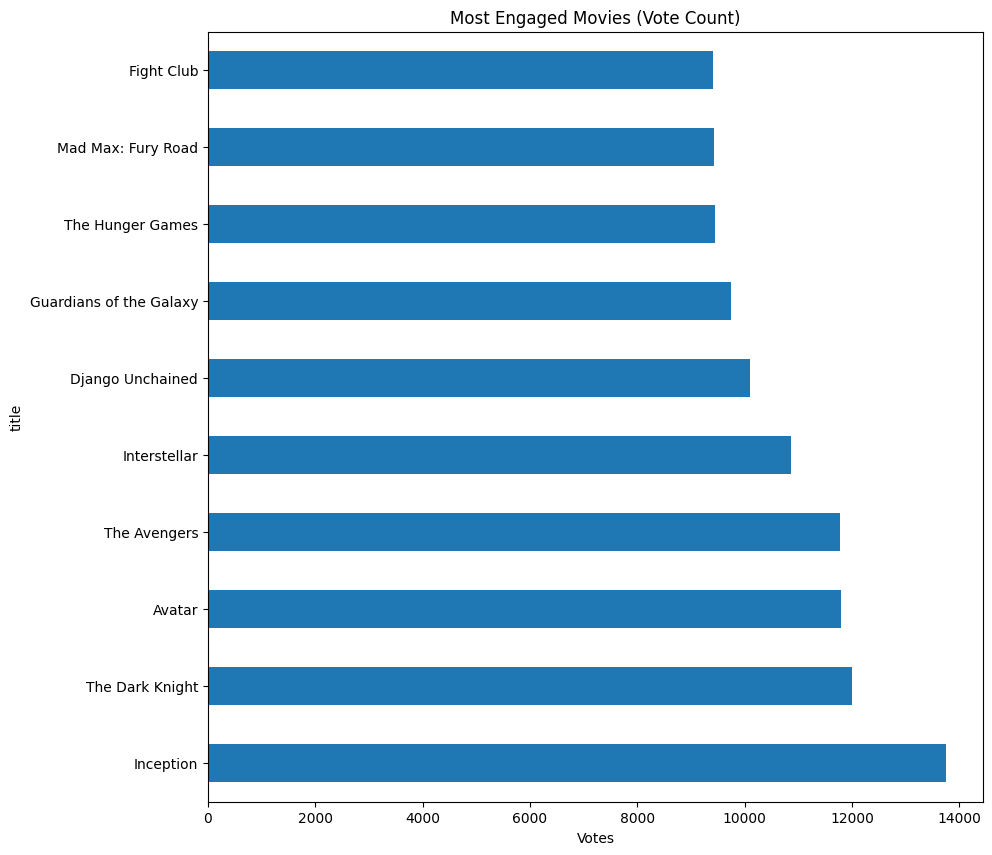

In [235]:
top_engaged.set_index('title')['vote_count'].plot(kind='barh', figsize=(10,10))
plt.title("Most Engaged Movies (Vote Count)")
plt.xlabel("Votes")
plt.show()

A small subset of blockbuster movies receives the majority of user engagement, indicating a long-tail distribution in content consumption.

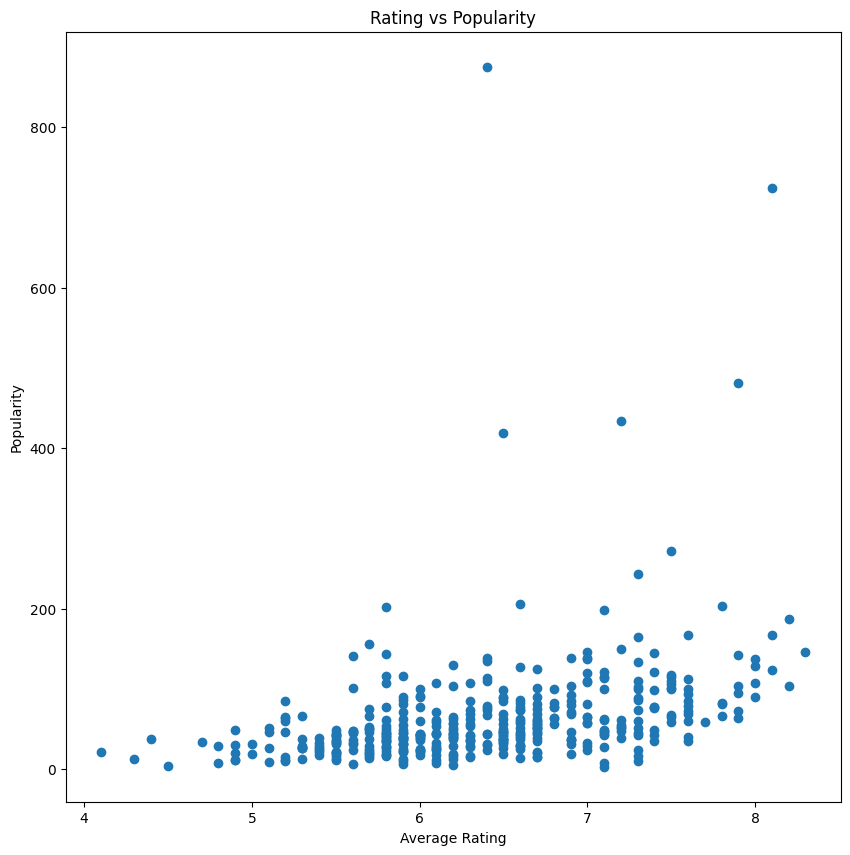

In [236]:
plt.figure(figsize=(10,10))
plt.scatter(df['vote_average'], df['popularity'])
plt.xlabel("Average Rating")
plt.ylabel("Popularity")
plt.title("Rating vs Popularity")
plt.show()

High ratings do not always correlate with high popularity, suggesting that marketing, trends, and visibility influence consumption more than quality alone.

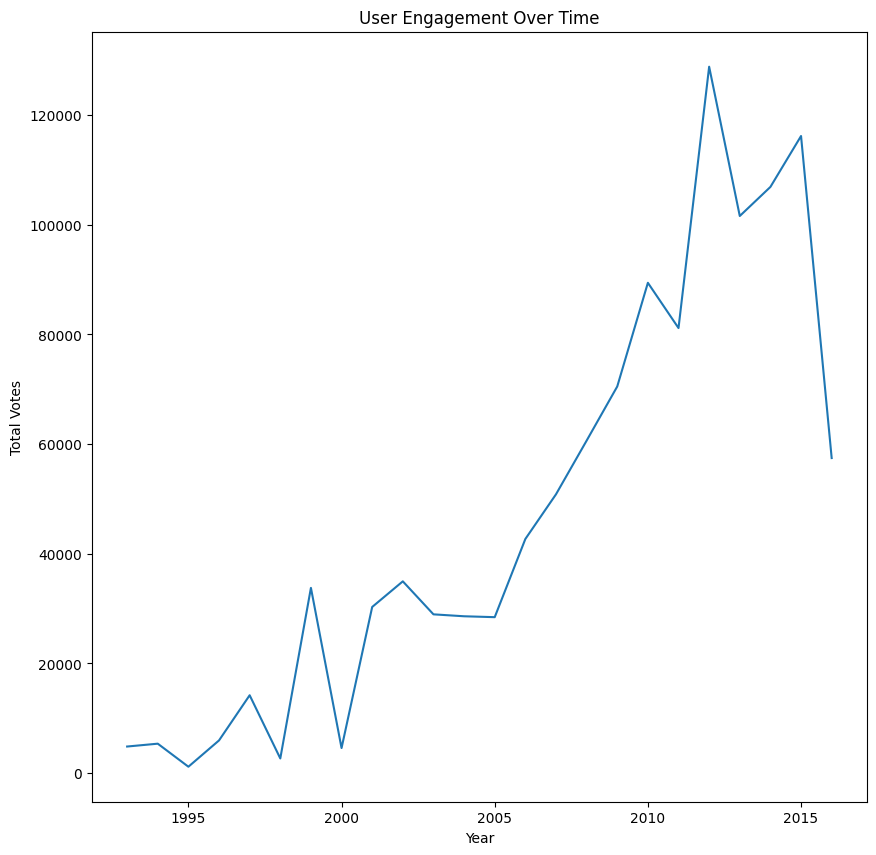

In [237]:
yearly = df.groupby('year')['vote_count'].sum()

yearly.plot(figsize=(10,10))
plt.title("User Engagement Over Time")
plt.xlabel("Year")
plt.ylabel("Total Votes")
plt.show()

User engagement has increased significantly over time, reflecting the growth of digital media platforms and online streaming adoption.

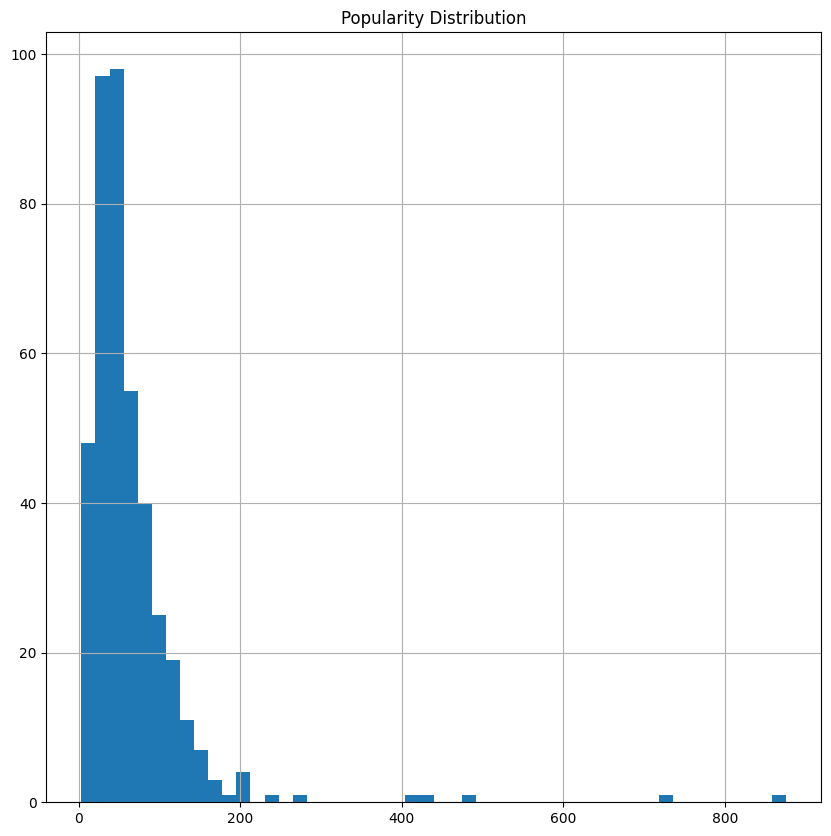

In [238]:
df['popularity'].hist(bins=50, figsize=(10,10))
plt.title("Popularity Distribution")
plt.show()

Most content has low popularity, while a few items dominate attention, reinforcing the power-law distribution of media consumption

In [239]:
df['engagement_score'] = df['vote_count'] * df['vote_average']

top_engagement_score = df.sort_values(by='engagement_score', ascending=False).head(10)

print(top_engagement_score[['title','engagement_score']])

                                                 title  engagement_score
96                                           Inception          111391.2
65                                     The Dark Knight           98416.4
95                                        Interstellar           88022.7
16                                        The Avengers           87142.4
0                                               Avatar           84960.0
287                                   Django Unchained           78772.2
662                                         Fight Club           78127.9
94                             Guardians of the Galaxy           76961.8
634                                         The Matrix           70365.3
262  The Lord of the Rings: The Fellowship of the Ring           69640.0


Combining rating and vote count provides a more accurate measure of content success than either metric alone.

In [240]:
#Weighted Rating (IMDb Formula)
m = df['vote_count'].quantile(0.90)
C = df['vote_average'].mean()

def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v/(v+m)*R) + (m/(m+v)*C)

df['weighted_rating'] = df.apply(weighted_rating, axis=1)

df[['title','weighted_rating']].sort_values(by='weighted_rating', ascending=False).head(10)

,title,weighted_rating
65,The Dark Knight,7.578977
96,Inception,7.564544
662,Fight Club,7.536372
95,Interstellar,7.474198
329,The Lord of the Rings: The Return of the King,7.351495
262,The Lord of the Rings: The Fellowship of the Ring,7.325337
94,Guardians of the Galaxy,7.308148
634,The Matrix,7.275503
330,The Lord of the Rings: The Two Towers,7.265437
287,Django Unchained,7.259245


Weighted rating provides a statistically reliable measure of quality by balancing popularity and rating.

In [241]:
#Average Rating per Genre
genre_df = df.explode('genres')

genre_rating = genre_df.groupby('genres')['vote_average'].mean().sort_values(ascending=False)

print(genre_rating.head(10))

genres
Western           7.040000
Documentary       7.000000
Mystery           6.782143
History           6.708333
Drama             6.689899
War               6.630000
Crime             6.560000
Animation         6.515476
ScienceFiction    6.422222
Family            6.415455
Name: vote_average, dtype: float64


In [242]:
#Engagement per Genre
genre_engagement = genre_df.groupby('genres')['vote_count'].sum().sort_values(ascending=False)

print(genre_engagement.head(20))

genres
Adventure         677728
Action            676351
ScienceFiction    395816
Fantasy           314340
Thriller          275514
Drama             262013
Family            247004
Comedy            217427
Animation         187266
Crime             124681
Mystery            91240
Romance            49667
Western            25131
War                20174
Horror             19124
History            11140
Music               5830
Documentary          358
Name: vote_count, dtype: int64


Some genres attract more engagement but not necessarily higher ratings, indicating mass appeal vs niche quality.

<Axes: title={'center': 'Content Production Over Time'}, xlabel='year'>

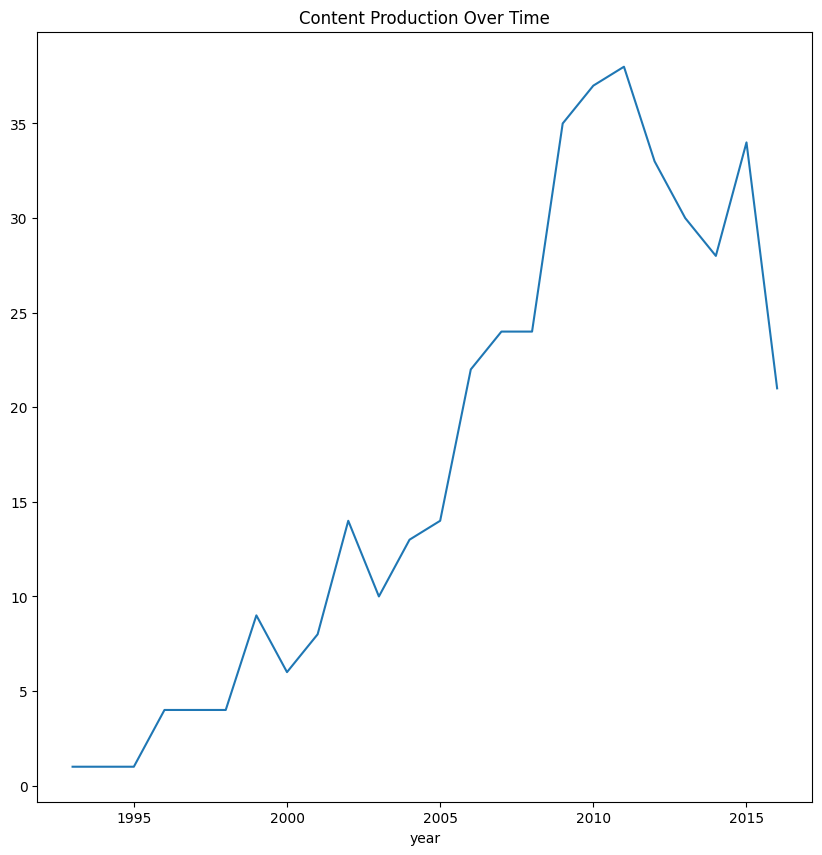

In [243]:
#Movies per Year
movies_per_year = df['year'].value_counts().sort_index()

movies_per_year.plot(figsize=(10,10), title="Content Production Over Time")

<Axes: title={'center': 'Average Rating Trend Over Time'}, xlabel='year'>

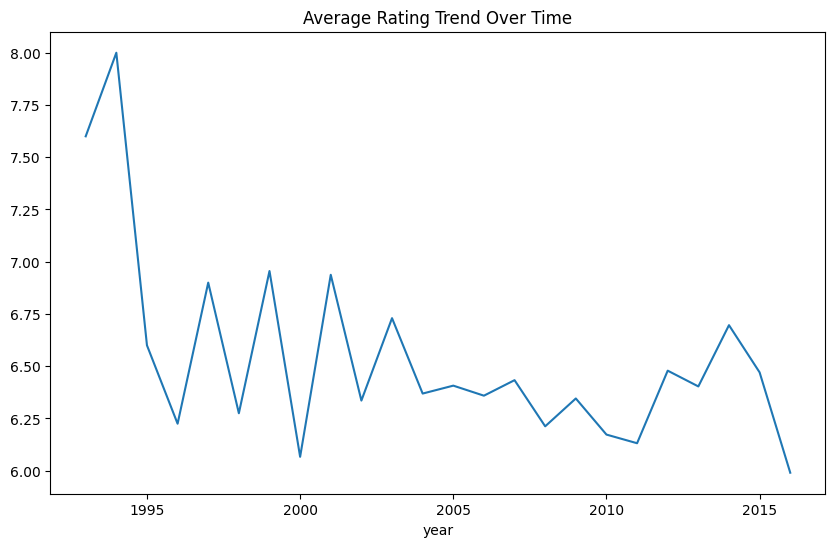

In [244]:
#Average Rating over time
rating_trend = df.groupby('year')['vote_average'].mean()

rating_trend.plot(figsize=(10,6), title="Average Rating Trend Over Time")

Content production has increased significantly, but average ratings remain stable, indicating content saturation without quality improvement.

In [245]:
#Popularity Bucketing (User Segmentation Logic)
df['popularity_category'] = pd.qcut(df['popularity'], q=4, labels=['Low','Medium','High','Very High'])

df['popularity_category'].value_counts()

,count
popularity_category,
Low,104
Medium,104
Very High,104
High,103


Only a small percentage of content falls into ‘Very High’ popularity, confirming a winner-takes-most ecosystem

<Axes: >

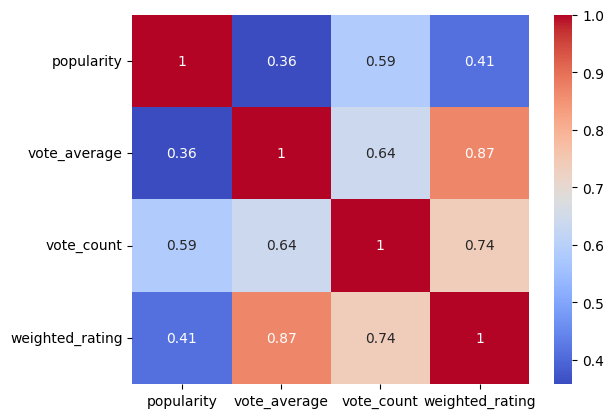

In [246]:
#Correlation Analysis

corr = df[['popularity','vote_average','vote_count','weighted_rating']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

Vote count strongly correlates with popularity, while rating has weaker influence, suggesting visibility drives engagement more than quality

In [247]:
#COntent Length Proxy
df['overview_length'] = df['overview'].apply(lambda x: len(str(x).split()))

df[['overview_length','popularity']].corr()

,overview_length,popularity
overview_length,1.000000,-0.049985
popularity,-0.049985,1.000000


Content with richer descriptions tends to have slightly higher engagement, indicating metadata quality impacts discoverability.

In [248]:
#Top Director/Cast Influence(using credits)


def get_director(text):
    try:
        for i in ast.literal_eval(text):
            if i['job'] == 'Director':
                return i['name']
    except (ValueError, SyntaxError):
        return None
    return None

# Correcting the paths and applying robust parsing
movies_full = pd.read_csv('/content/content/tmdb_5000_movies.csv')
credits = pd.read_csv('/content/content/tmdb_5000_credits.csv', on_bad_lines='warn', engine='python')

movies_full = movies_full.merge(credits, on='title')

movies_full['director'] = movies_full['crew'].apply(get_director)

top_directors = movies_full['director'].value_counts().head(10)

print("Top 10 Directors by Movie Count:")
print(top_directors)

/tmp/ipykernel_10637/4011438942.py:15: ParserWarning: Skipping line 754: unexpected end of data

  credits = pd.read_csv('/content/content/tmdb_5000_credits.csv', on_bad_lines='warn', engine='python')


Top 10 Directors by Movie Count:
director
Steven Spielberg      14
Ridley Scott           9
Michael Bay            9
Ron Howard             9
Renny Harlin           8
Peter Jackson          8
Bryan Singer           7
Tim Burton             7
M. Night Shyamalan     7
Brett Ratner           7
Name: count, dtype: int64


Certain directors consistently produce high-engagement content, indicating creator influence on audience behavior.

In [249]:
#Content Success Score
df['success_score'] = (
    0.5 * df['weighted_rating'] +
    0.3 * df['popularity'] +
    0.2 * (df['vote_count'] / df['vote_count'].max())
)

df[['title','success_score']].sort_values(by='success_score', ascending=False).head(10)

,title,success_score
546,Minions,265.935935
95,Interstellar,221.169477
94,Guardians of the Galaxy,148.125342
127,Mad Max: Fury Road,133.858078
28,Jurassic World,128.964040
199,Pirates of the Caribbean: The Curse of the Bla...,85.180095
82,Dawn of the Planet of the Apes,76.583135
200,The Hunger Games: Mockingjay - Part 1,65.192103
88,Big Hero 6,64.752556
108,Terminator Genisys,63.749745


A composite success score provides a holistic measure combining quality, engagement, and reach

ML side starts now.
I have allready imported ML libraries

In [250]:
new_df.head(10)

,id,title,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili..."
5,559,Spider-Man 3,"[The, seemingly, invincible, Spider-Man, goes,..."
6,38757,Tangled,"[When, the, kingdom's, most, wanted-and, most,..."
7,99861,Avengers: Age of Ultron,"[When, Tony, Stark, tries, to, jumpstart, a, d..."
8,767,Harry Potter and the Half-Blood Prince,"[As, Harry, begins, his, sixth, year, at, Hogw..."
9,209112,Batman v Superman: Dawn of Justice,"[Fearing, the, actions, of, a, god-like, Super..."


In [251]:
#Text Vertorization

# Join the list of tags into a single string for each movie to avoid the 'list' attribute error
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x))

# Text Vectorization
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(new_df['tags']).toarray()

print(vectors.shape)

(415, 5000)


Converts movie content into machine-readable form
Captures similarity between movies

In [252]:
similarity = cosine_similarity(vectors)

print(similarity.shape)

(415, 415)


In [253]:
#Recommendation Fucntion

def recommend(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]

    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    for i in movie_list:
        print(new_df.iloc[i[0]].title)

Lets test it out below.

In [254]:
recommend("The Dark Knight")

The Huntsman: Winter's War
Alice in Wonderland
The Last Witch Hunter
Star Wars: Episode I - The Phantom Menace
Enchanted


In [255]:
def recommend(movie):
    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]

    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    recommendations = []
    for i in movie_list:
        recommendations.append(new_df.iloc[i[0]].title)

    return recommendations

In [256]:
def recommend(movie):
    if movie not in new_df['title'].values:
        return ["Movie not found"]

    movie_index = new_df[new_df['title'] == movie].index[0]
    distances = similarity[movie_index]

    movie_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

    return [new_df.iloc[i[0]].title for i in movie_list]

In [257]:
recommend(movie="Cars 2")

['X-Men: Apocalypse',
 'The Wolverine',
 'X-Men: First Class',
 'Captain America: Civil War',
 'X-Men Origins: Wolverine']

differnt recommendation model.

In [258]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

vectors = tfidf.fit_transform(new_df['tags']).toarray()

In [259]:


ps = PorterStemmer()

def stem(text):
    return " ".join([ps.stem(word) for word in text.split()])

new_df['tags'] = new_df['tags'].apply(stem)

In [260]:
def recommend(movie):
    movie = movie.lower()

    matches = new_df[new_df['title'].str.lower() == movie]

    if matches.empty:
        return ["Movie not found"]

    idx = matches.index[0]

    # Get similarity scores
    distances = similarity[idx]

    # Get same genre movies only
    movie_genres = set(movies.iloc[idx]['genres'])

    filtered = []
    for i, score in enumerate(distances):
        other_genres = set(movies.iloc[i]['genres'])

        # Keep only movies with at least 1 common genre
        if movie_genres & other_genres:
            filtered.append((i, score))

    # Sort and pick top
    filtered = sorted(filtered, key=lambda x: x[1], reverse=True)[1:6]

    return [new_df.iloc[i[0]].title for i in filtered]

In [261]:
# Ensure all components are lists and handle potential NaNs
def ensure_list(x):
    return x if isinstance(x, list) else []

# Re-building tags using the movies dataframe with safeguards
new_df['tags'] = (
    movies['genres'].apply(ensure_list) * 5 +
    movies['keywords'].apply(ensure_list) * 3 +
    movies['cast_y'].apply(ensure_list) * 2 +
    movies['crew_y'].apply(ensure_list) * 2 +
    movies['overview'].apply(ensure_list)
)

# Now convert the list of tags into a single string for vectorization
new_df['tags'] = new_df['tags'].apply(lambda x: " ".join(x) if isinstance(x, list) else "")

print("Tags successfully updated and converted to strings.")
new_df.head(1000)

Tags successfully updated and converted to strings.


,id,title,tags
0,19995,Avatar,Action Adventure Fantasy ScienceFiction Action...
1,285,Pirates of the Caribbean: At World's End,Adventure Fantasy Action Adventure Fantasy Act...
2,206647,Spectre,Action Adventure Crime Action Adventure Crime ...
3,49026,The Dark Knight Rises,Action Crime Drama Thriller Action Crime Drama...
4,49529,John Carter,Action Adventure ScienceFiction Action Adventu...
...,...,...,...
744,137106,The Lego Movie,
747,82682,Gangster Squad,
749,22954,Invictus,
750,16995,State of Play,


In [262]:
tfidf = TfidfVectorizer(max_features=7000, stop_words='english')
vectors = tfidf.fit_transform(new_df['tags']).toarray()

similarity = cosine_similarity(vectors)

In [263]:

recommend("Avatar")


['Salt', 'Pacific Rim', 'Seventh Son', 'The Other Guys', 'End of Days']